# Análise de nanotoxicidade em nanopartículas por algorítmo *k*-NN

**Disciplina:** Aprendizado de máquina

**Docente:** Daniel Roberto Cassar 

**Discente e autor:** Leonardo Ramos Gomes da Silva 

## Introdução

Este caderno demonstra a implementação do algorítmo de *k*-**vizinhos mais próximos** (*k*-NN) a fim de prever a toxicidade de nanopartículas (NPs), baseado em diversos atributos, tais como: o material de que são feitas, o tamanho do núcleo, o tamanho hidrodinâmico, a carga de superfície, a área de superfície, a energia de valência, a eletronegatividade, o tempo de exposição e a dosagem. O banco de dados utilizado é o *"Nanoparticle Toxicity Dataset"*, disponibilizado pela plataforma Kaggle. A finalidade do caderno não é prover o melhor modelo para fazer a previsão, mas realizar um estudo em torno desse modelo e a sua aplicação com o módulo `scikit`.

## Tratamento de dados

O banco de dados será então introduzido e tratado. O método `df.dropna`, do módulo `pandas`, é utilizado para garantitr que não tenham exemplos com dados indisponíveis para a análise.

In [1]:
import pandas as pd

df = pd.read_csv("nanotox_dataset.csv")

ATRIBUTOS = ["NPs", "coresize", "hydrosize", "surfcharge", "surfarea", "Ec", "e",
       "Expotime", "dosage"]
TARGET = ["class"]

x = df.reindex(ATRIBUTOS, axis=1)
y = df.reindex(TARGET, axis=1)

df = df.reindex(ATRIBUTOS + TARGET, axis=1)
df = df.dropna()

Vejamos os atributos.

In [2]:
x

,NPs,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage
0,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.001
1,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.010
2,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.100
3,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,1.000
4,Al2O3,39.7,267.0,36.3,64.7,-1.51,1.61,24,5.000
...,...,...,...,...,...,...,...,...,...
876,ZnO,45.3,310.0,32.7,21.3,-3.89,1.65,24,20.000
877,ZnO,32.0,1093.0,21.6,37.0,-3.89,1.65,24,25.000
878,ZnO,46.3,239.0,42.8,24.1,-5.17,1.90,12,100.000
879,ZnO,35.6,295.5,-41.6,27.9,-3.89,1.65,24,10.000


Vejamos o target.

In [3]:
y

,class
0,nonToxic
1,nonToxic
2,nonToxic
3,nonToxic
4,nonToxic
...,...
876,Toxic
877,Toxic
878,Toxic
879,Toxic


Antes de seguir em frente, o atributo `NPs` será convertido em número, utilizando a técnica do One Hot Encoder [1]. funciona assim e assado

In [4]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform="pandas")

encoded_df = encoder.fit_transform(df[['NPs']])

df = pd.concat([df, encoded_df], axis=1).drop(columns=['NPs'])

df

,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage,class,NPs_Al2O3,NPs_CuO,NPs_Fe2O3,NPs_TiO2,NPs_ZnO
0,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.001,nonToxic,1.0,0.0,0.0,0.0,0.0
1,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.010,nonToxic,1.0,0.0,0.0,0.0,0.0
2,39.7,267.0,36.3,64.7,-1.51,1.61,24,0.100,nonToxic,1.0,0.0,0.0,0.0,0.0
3,39.7,267.0,36.3,64.7,-1.51,1.61,24,1.000,nonToxic,1.0,0.0,0.0,0.0,0.0
4,39.7,267.0,36.3,64.7,-1.51,1.61,24,5.000,nonToxic,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,45.3,310.0,32.7,21.3,-3.89,1.65,24,20.000,Toxic,0.0,0.0,0.0,0.0,1.0
877,32.0,1093.0,21.6,37.0,-3.89,1.65,24,25.000,Toxic,0.0,0.0,0.0,0.0,1.0
878,46.3,239.0,42.8,24.1,-5.17,1.90,12,100.000,Toxic,0.0,0.0,0.0,0.0,1.0
879,35.6,295.5,-41.6,27.9,-3.89,1.65,24,10.000,Toxic,0.0,0.0,0.0,0.0,1.0


Vejamos o tamanho do banco de dados utilizado.

In [5]:
df.shape

(881, 14)

Utilizando o método `describe()` para analisar a diferença média geral entre nanopartículas não tóxicas e tóxicas para uma rápida análise. A primeira será das partículas não tóxicas.

In [6]:
#Describe em partículas não tóxicas
logica = df["class"] == "nonToxic"

df.loc[logica].describe()

,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage,NPs_Al2O3,NPs_CuO,NPs_Fe2O3,NPs_TiO2,NPs_ZnO
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,47.966667,522.805185,-4.405432,61.107654,-3.997210,1.610321,21.977778,31.803132,0.044444,0.027160,0.044444,0.479012,0.404938
std,31.236046,411.580450,22.644049,60.172709,0.611865,0.086306,18.077172,46.244915,0.206335,0.162752,0.206335,0.500177,0.491487
min,7.500000,74.000000,-41.600000,7.000000,-5.170000,1.540000,3.000000,0.000010,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,267.000000,-11.700000,20.000000,-4.160000,1.540000,6.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,35.600000,310.000000,-10.700000,40.000000,-4.160000,1.610000,24.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60.000000,687.000000,-2.400000,66.000000,-3.890000,1.650000,24.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,125.000000,1843.000000,42.800000,210.000000,-1.510000,1.900000,72.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Abaixo está o método `describe()` apenas em partículas tóxicas.

In [7]:
#Describe em partículas tóxicas

df.loc[~logica].describe()

,coresize,hydrosize,surfcharge,surfarea,Ec,e,Expotime,dosage,NPs_Al2O3,NPs_CuO,NPs_Fe2O3,NPs_TiO2,NPs_ZnO
count,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.0,476.000000,476.0,476.000000,476.000000
mean,63.414916,506.103571,6.787605,25.879538,-4.035924,1.676450,32.123950,46.328782,0.0,0.084034,0.0,0.012605,0.903361
std,34.121298,279.919506,26.901897,21.463784,0.402980,0.080159,19.534783,27.966269,0.0,0.277730,0.0,0.111680,0.295776
min,7.500000,236.000000,-41.600000,7.000000,-5.170000,1.540000,3.000000,10.000000,0.0,0.000000,0.0,0.000000,0.000000
25%,35.600000,273.400000,-11.700000,14.500000,-3.890000,1.650000,24.000000,25.000000,0.0,0.000000,0.0,0.000000,1.000000
50%,52.000000,360.000000,-2.400000,20.000000,-3.890000,1.650000,24.000000,50.000000,0.0,0.000000,0.0,0.000000,1.000000
75%,100.000000,687.000000,29.400000,27.900000,-3.890000,1.650000,48.000000,50.000000,0.0,0.000000,0.0,0.000000,1.000000
max,125.000000,1093.000000,42.800000,90.000000,-3.890000,1.900000,72.000000,100.000000,0.0,1.000000,0.0,1.000000,1.000000


Em primeiro, percebe-se que há mais exemplos de nanopartículas tóxicas. As médias e medianas informam que, em nanopartículas tóxicas, o tamanho do núcleo tende a ser maior e o tamanho hidrodinâmico menor - ou seja, o intervalo entre esses tamanhos diminui. Além disso, a área de superfície tende a ser menor, o que está associado com uma maior carga de superfície, visível nos dados. Além disso, os atributos de tempo de exposição e dosagem tendem a ser maiores em nanopartículas tóxicas, assumo, portanto, que são os valores que mais influenciam na visualização da toxicidade de uma nanopartícula. Este último tópico será discutido mais adiante.

No gráfico 1 abaixo também é possível visualizar que os dados estão desbalanceados no que tange ao material da nanopartícula, pois há muito mais de ZnO. É possível, dessa forma, que ao realizar a separação entre treino e teste muitas partículas de ZnO sejam utilizadas para treino em detrimento dos outros tipos.

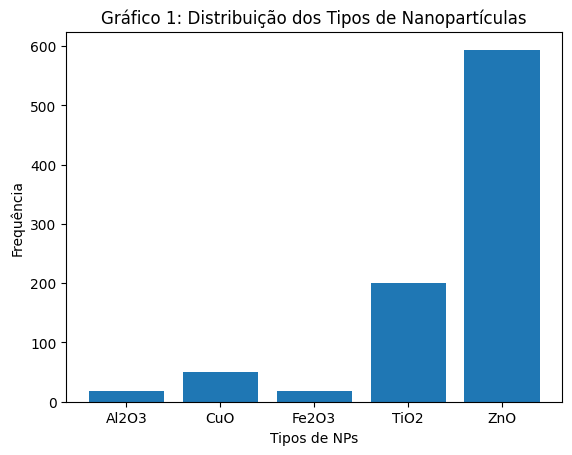

In [8]:
import matplotlib.pyplot as plt

distribuicao = [df.loc[df["NPs_Al2O3"] == 1].shape[0],
                df.loc[df["NPs_CuO"] == 1].shape[0],
                df.loc[df["NPs_Fe2O3"] == 1].shape[0],
                df.loc[df["NPs_TiO2"] == 1].shape[0],
                df.loc[df["NPs_ZnO"] == 1].shape[0]]

plt.bar(range(len(distribuicao)), distribuicao)
plt.xlabel("Tipos de NPs")
plt.ylabel("Frequência")
plt.title("Gráfico 1: Distribuição dos Tipos de Nanopartículas")
plt.xticks(range(len(distribuicao)), ["Al2O3", "CuO", "Fe2O3", "TiO2", "ZnO"])
plt.show()

Além disso, as nanopartículas de Al2O3 e Fe2O3 são todas não tóxicas, como pode-se ver na média acima. Todavia, na atualização dos ATRIBUTOS após a técnica do *OneHotEncoder*, nanopartículas desses materiais não serão retiradas pois ainda constituem dados válidos.

In [9]:
ATRIBUTOS = ["NPs_Al2O3", "NPs_CuO", "NPs_Fe2O3", "NPs_TiO2", "NPs_ZnO", "coresize", 
       "hydrosize", "surfcharge", "surfarea", "Ec", "e",
       "Expotime", "dosage"]


df = df.reindex(ATRIBUTOS + TARGET, axis=1)

## Gráficos 

Os gráficos abaixo mostram cada característica isoladamente para cada tipo de nanopartícula para rápida análise de possíveis correlações.

No gráfico 2, feito com o módulo `matplotlib` e auxílio da Inteligência Artificial (IA) Copylot, há os dados da "dosage" (dosagem) e "Expotime" (tempo de exposição), vistos como os atributos que mais influenciam na visualização de toxicidade de uma nanopartícula anteriormente. O gráfico consiste na visualização dos dados gerais de todas as NPs e dados específicos das NPs de ZnO, escolhidas por serem as com mais dados. O gráfico foi feito com variação na opacidade dada a densidade de pontos da mesma cor no mesmo local, sendo os mais claros menos densos e mais escuros com mais pontos repetidos na mesma coordenada. 

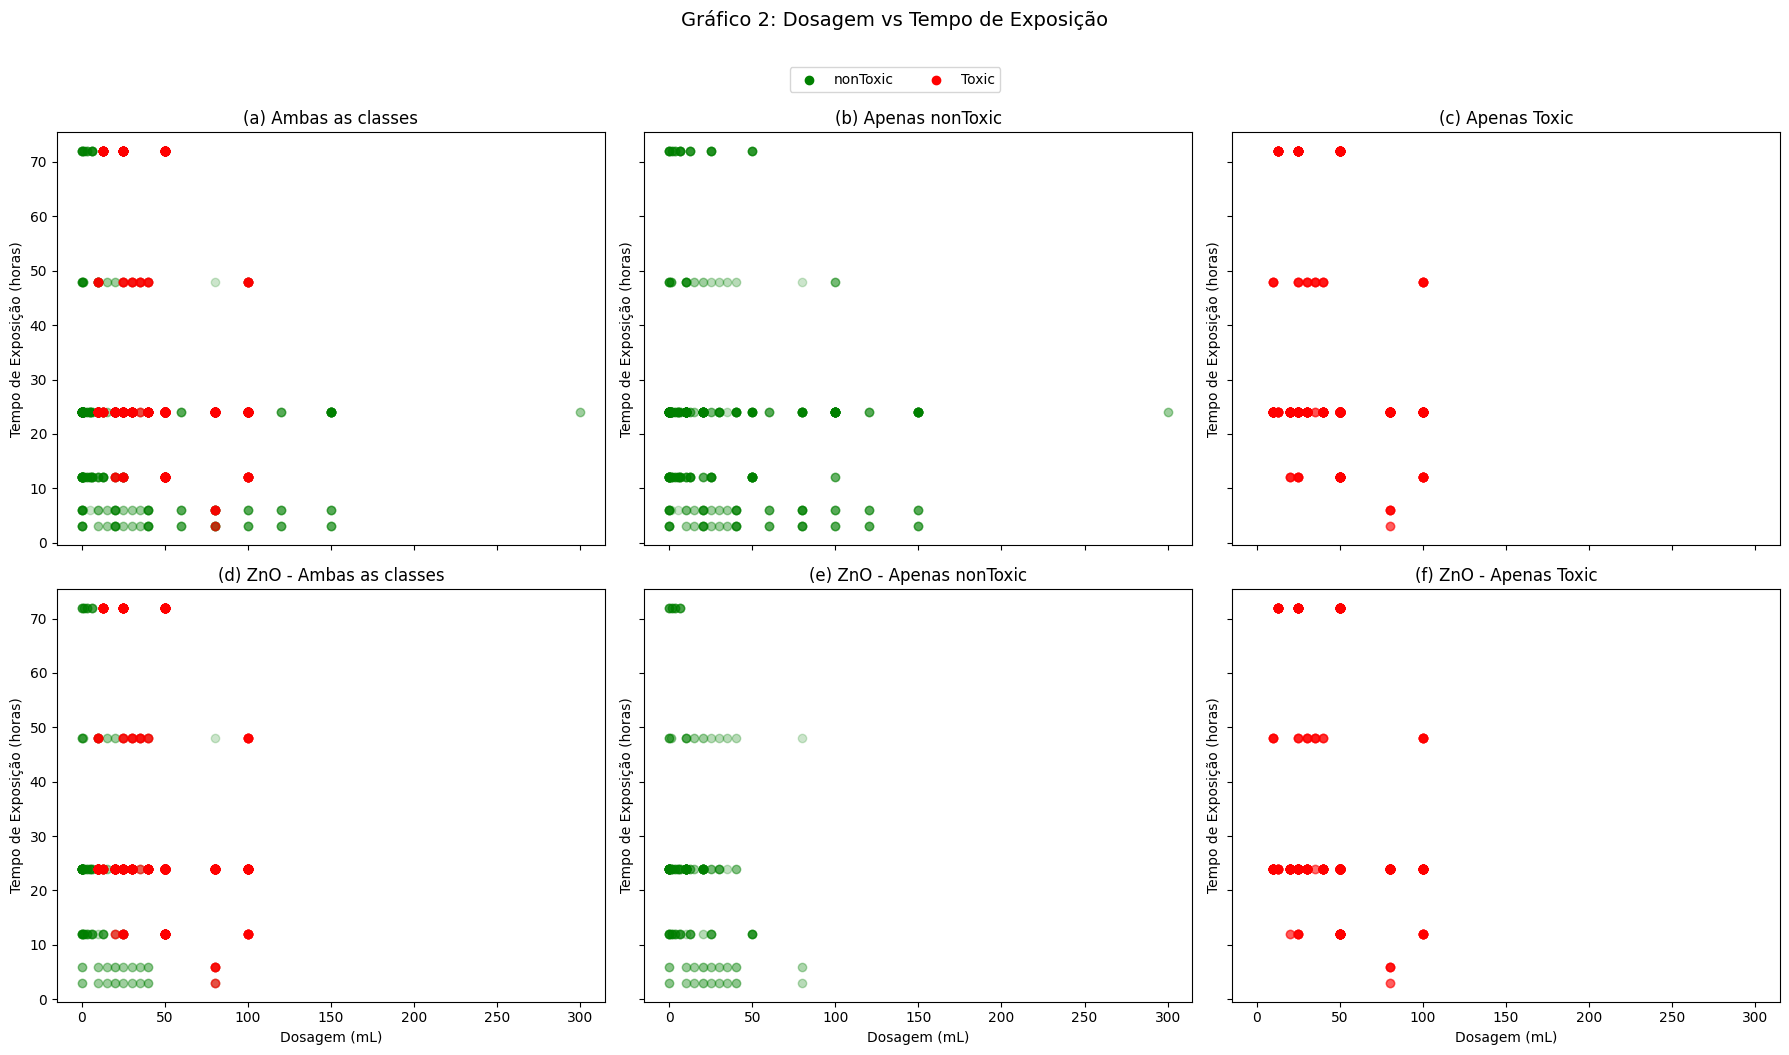

In [34]:
import matplotlib.pyplot as plt

# Copia o dataframe completo
df_plot = df.copy()

# Conta repetições de cada ponto
df_plot["contagem"] = (
    df_plot.groupby(["dosage", "Expotime"])["dosage"]
    .transform("size")
)

# Normaliza para alpha entre 0.2 e 1.0
c_min = df_plot["contagem"].min()
c_max = df_plot["contagem"].max()

if c_max == c_min:
    df_plot["alpha"] = 1.0
else:
    df_plot["alpha"] = 0.2 + 0.8 * (
        (df_plot["contagem"] - c_min) / (c_max - c_min)
    )

# Apenas ZnO
df_zno = df_plot[df_plot["NPs_ZnO"] == 1]

# Painel 2 x 3
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

# -------------------------
# (a) Ambas as classes
# -------------------------
ax = axes[0, 0]

for _, row in df_plot[df_plot["class"] == "nonToxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="green", alpha=row["alpha"])

for _, row in df_plot[df_plot["class"] == "Toxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="red", alpha=row["alpha"])

ax.set_title("(a) Ambas as classes")
ax.set_ylabel("Tempo de Exposição (horas)")

# -------------------------
# (b) Apenas nonToxic
# -------------------------
ax = axes[0, 1]

for _, row in df_plot[df_plot["class"] == "nonToxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="green", alpha=row["alpha"])

ax.set_title("(b) Apenas nonToxic")
ax.set_ylabel("Tempo de Exposição (horas)")

# -------------------------
# (c) Apenas Toxic
# -------------------------
ax = axes[0, 2]

for _, row in df_plot[df_plot["class"] == "Toxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="red", alpha=row["alpha"])

ax.set_title("(c) Apenas Toxic")
ax.set_ylabel("Tempo de Exposição (horas)")

# -------------------------
# (d) ZnO - Ambas as classes
# -------------------------
ax = axes[1, 0]

for _, row in df_zno[df_zno["class"] == "nonToxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="green", alpha=row["alpha"])

for _, row in df_zno[df_zno["class"] == "Toxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="red", alpha=row["alpha"])

ax.set_title("(d) ZnO - Ambas as classes")
ax.set_xlabel("Dosagem (mL)")
ax.set_ylabel("Tempo de Exposição (horas)")

# -------------------------
# (e) ZnO - Apenas nonToxic
# -------------------------
ax = axes[1, 1]

for _, row in df_zno[df_zno["class"] == "nonToxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="green", alpha=row["alpha"])

ax.set_title("(e) ZnO - Apenas nonToxic")
ax.set_xlabel("Dosagem (mL)")
ax.set_ylabel("Tempo de Exposição (horas)")
# -------------------------
# (f) ZnO - Apenas Toxic
# -------------------------
ax = axes[1, 2]

for _, row in df_zno[df_zno["class"] == "Toxic"].iterrows():
    ax.scatter(row["dosage"], row["Expotime"],
               color="red", alpha=row["alpha"])

ax.set_title("(f) ZnO - Apenas Toxic")
ax.set_xlabel("Dosagem (mL)")
ax.set_ylabel("Tempo de Exposição (horas)")

# Legenda geral
handles = [
    plt.scatter([], [], color="green", label="nonToxic"),
    plt.scatter([], [], color="red", label="Toxic")
]

fig.legend(handles=handles,
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 1.00))

plt.suptitle(
    "Gráfico 2: Dosagem vs Tempo de Exposição",
    fontsize=14,
    y=1.05
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

Como suposto anteriormente com as médias entre as diferentes classes, as NPs não tóxicas, apesar da grande variância, têm maior concentração em áreas com menor tempo de exposição, especialmente com baixa dosagem (Fig. 2a e 2b). Permanece certo ceticismo em torno dessa visão pela presença de NPs tóxicas em pontos iguais, senão idênticos, aos de não tóxicas (Fig. 2c), parecendo não haver real regra, apenas uma sutil tendência. 

Todavia, ao analisar apenas as ZnO_NPs há visível correlação entre dosagem e tempo de exposição, pois todas as extremidades à esquerda (com menor dosagem) são não tóxicas enquanto as extremidades vermelhas (com maior dosagem) são tóxicas. Além disso, parece ter havido mais testes com o tempo de exposição de 24 segundos, visto que há mais densidade de pontos nessa área, sendo também visível que quanto mais deslocado à direita mais pontos vermelhos.

## Treinando o modelo

Importando a biblioteca *scikit-learn* com o método `train_test_split` a fim de realizar o treinamento do modelo para o algorítmo de *k* vizinhos-próximos. A `SEMENTE_ALEATORIA` foi decidida arbitrariamente pelo autor a fim de criar reprodutibilidade nos dados.

O tamanho do teste foi escolhido com 10% pois o arquivo tem bastante exemplos, o que gera uma boa parcela de teste e um grande número de dados restantes para treinar o algorítmo.

In [11]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.10
SEMENTE_ALEATORIA = 73701

indices = df.index

indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA,stratify=df[TARGET]
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

x_treino = df_treino[ATRIBUTOS]
y_treino = df_treino[TARGET].values.ravel()

x_teste = df_teste[ATRIBUTOS]
y_teste = df_teste[TARGET].values.ravel()

Como os dados estão em escalas diferentes (alta diferença entre tamanho hidrodinâmico e eletronegatividade, por exemplo), será realizada a normalização desses dados com o método `StandartScaler`.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_treino_padronizado = scaler.fit_transform(
    x_treino
)

x_teste_padronizado = scaler.transform(
    x_teste
)

A fim de classificar de forma binária deve haver uma ordem específica.

In [13]:
ordem_labels = df["class"].unique().tolist()

ordem_labels

['nonToxic', 'Toxic']

## Modelo Baseline

O método `DummyClassifier` criará um modelo de *baseline* para analisar mais a frente a eficiência do modelo mais complexo. O método `fit` tem função de armazenar na memória o modelo treinado. Abaixo o modelo é treinado.

In [14]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()
modelo_baseline.fit(x_treino_padronizado, y_treino)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.54,0.46]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","['Toxic','nonToxic']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,13
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


Importando o método `confusion_matrix` para criar uma visualização gráfica da matriz de confusão. Essa matriz retorna os tipos de acertos e tipos de erros na previsão. Os possíveis acertos são: verdadeiro positivo (VP), quando a NP real é tóxica e a predita é, também, tóxica, e verdadeiro negativo (VN), quando a NP real é não tóxica e a predita é, também, não tóxica. Os possíveis erros são: falso positivo (FP), quando a NP real é não tóxica e é predita como tóxica, e falso negativo (FN), quando a NP real é não tóxica e é predita como tóxica. 

Vale pontuar que todo erro deve ser evitado, mas, nesse caso de predição de toxicidade, o FN é mais perigoso. Isso ocorre pois o FN, provavelmente, fornece confiança de manejo com menos cuidado que o necessário de NPs que são, na realidade, tóxicas. Enquanto isso, o FP apenas provê maior cuidado possivelmente desnecessário.

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(x_teste_padronizado)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_baseline = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

O resultado de acurácia do modelo Baseline pode ser visualizada no gráfico 3.

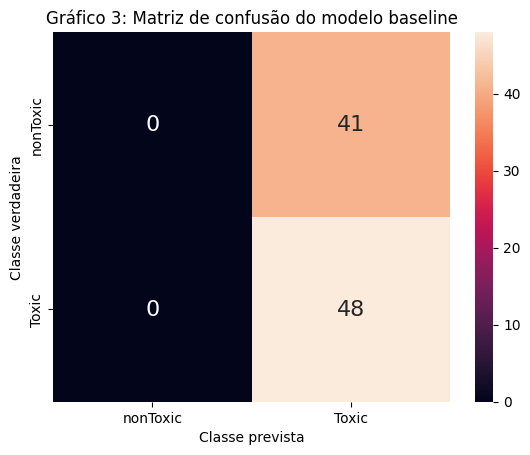

In [16]:
sns.heatmap(df_conf_baseline, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 3: Matriz de confusão do modelo baseline")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

Dada a matriz de confusão com as bibliotecas *scikit-learn* e *seaborn*, a fim de medir o desempenho do modelo apenas com base nas previsões certas e erradas, será utilizada a acurácia (1). A acurácia é uma boa métrica de desempenho nesse caso porque os dados (na categorização binária) estão relativamente balanceados e é direta pois mostra a porcentagem de acerto do modelo.

\begin{equation}
\mathrm{ACC = \frac{VP + VN}{VP + FP + VN + FN}}
\end{equation}

A acurácia do modelo Baseline pode ser vista abaixo:

In [17]:
from sklearn.metrics import accuracy_score

acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do modelo Baseline = {(acuracia_baseline*100):.2f}%")

Acurácia do modelo Baseline = 53.93%


Ao criar o modelo Baseline, este utiliza, com dados categóricos de classificação binária, a moda de todos os dados a fim de fazer a previsão, ou seja, é um modelo muito incerto. Pode-se perceber que a alta incerteza do modelo se deu pois não há discrepância entre a quantidade de tóxicos e não tóxicos. A acurácia do Baseline de apenas 54.14% nos incentiva, portanto, a procurar melhores modelos para classificação.

O modelo utilizado, no caso, será o *k* vizinhos próximos.

## Implementação do *k*-NN

O *k*-NN importado da biblioteca *scikit* será o `KNeighborsClassifier`, pois o problema a ser resolvido neste caderno é de classificação binária, visto que pode ser apenas ou tóxico ou não tóxico. Abaixo o modelo é treinado com o hiperparâmetro de número de vizinhos igual a 3 por ser um número baixo diferente de zero. Além disso, a distância calculada será a euclidiana e todos os vizinhos terão o mesmo peso. Mais adiante serão realizadas variações nesses hiperparâmetros a fim de deduzir o melhor modelo. O modelo é treinado abaixo.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(x_treino_padronizado, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['Toxic','nonToxic']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Abaixo a variável `y_previsao` receberá os valores previstos pelo modelo, após treinado, ao classificar os dados da variável `x_teste_padronizado`.

In [19]:
y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(x_teste_padronizado)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_knn = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

A matriz de confusão com o modelo *k*-NN pode ser vista no gráfico 4.

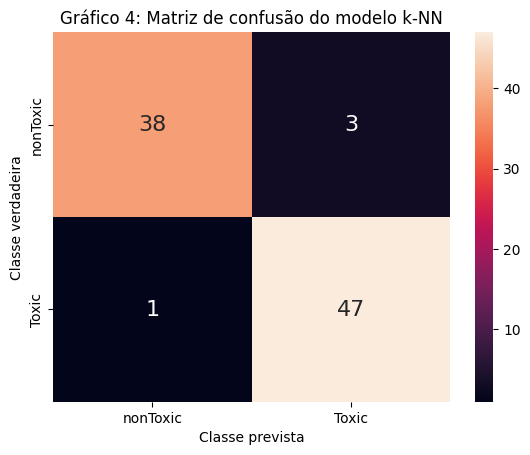

In [20]:
sns.heatmap(df_conf_knn, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 4: Matriz de confusão do modelo k-NN")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

Calculando a acurácia desse modelo.


In [21]:
acuracia_knn = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do modelo k-NN = {(acuracia_knn*100):.2f}%")

Acurácia do modelo k-NN = 95.51%


Com o modelo *k*-NN houve um aumento exorbitante na acurácia quando comparado ao Baseline, de aproximadamente 42%. Uma possível razão para essa alta acurácia é que os dados sejam bem separados que, em conjunto com o baixo número de vizinhos, performou muito bem. Mais adiante, com a variação dos hiperparâmetros, a questão da boa separação entre as classes será discutida. É interessante notar que houve apenas um falso positivo, dentre as quatro classificações errôneas. Isso nos dá um bom indicativo de que, mesmo havendo erros, é menos provável que seja cometido o erro mais grave. 

Abaixo há o treinamento do modelo utilizando o regressor logístico. Esse modelo consiste na [INSERIR EXPLICAÇÃOOOOOOOOO]

In [22]:
from sklearn.linear_model import LogisticRegression

modelo_rlog = LogisticRegression(max_iter=5000)
modelo_rlog.fit(x_treino_padronizado, y_treino)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Criando a matriz confusão com as previsões do Regressor Logístico.

In [23]:
y_verdadeiro = y_teste
y_previsao = modelo_rlog.predict(x_teste_padronizado)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_regressor = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

Demonstrando visualmente no gráfico 5 os erros e acertos do modelo

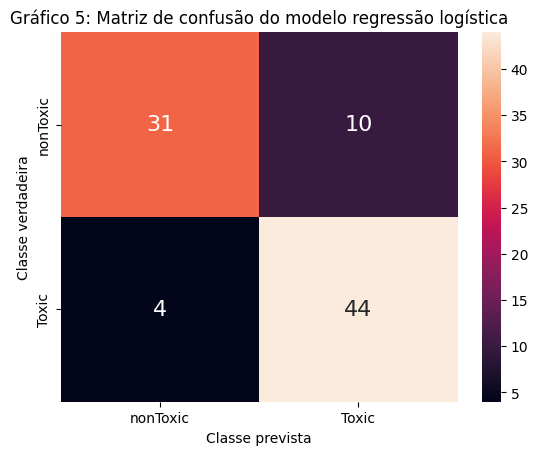

In [24]:
sns.heatmap(df_conf_regressor, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 5: Matriz de confusão do modelo regressão logística")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

In [25]:
acuracia_regressor = accuracy_score(y_verdadeiro, y_previsao)

In [26]:
print(f"Acurácia do modelo com Regressor Logístico = {(acuracia_regressor*100):.2f}%")

Acurácia do modelo com Regressor Logístico = 84.27%


A acurácia do modelo com Regressor Logístico diminuiu em relação ao *k*-NN puro, evidenciando não ser um bom modelo. Para além disso, outro fator importante para descartar o modelo é a quantidade de FPs maior que o modelo do gráfico 2, tornando o modelo até mesmo mais perigoso ao ser utilizado em laboratório, que o anterior. A diminuição na acurácia provavelmente se dá por conta [INSERIR ALGUMA DISCUSSÃO]

## Variação de hiperparâmetros

A fim de escolher o melhor conjunto de hiperparâmetros, como o problema é NP-difícil, temos que testar vários conjuntos e visualizar seus resultados. Assim, serão feitas variações na variável de vizinhos `k` com valores de [3, 5, 7], na forma como o cálculo da distância é feito (euclidiana, manhattan e minkowski) e no peso da distância (sem peso, com peso).

In [27]:
from itertools import product

NUM_VIZINHOS = [1, 3, 5, 7]
NUM_DISTANCIA = [1, 2, 3]  # 1 Manhattan, 2 Euclidiana, 3 Minkowski
TIPO_PESO = ["uniform", "distance"]

for n_vizinhos, p_distancia, peso in product(
    NUM_VIZINHOS, NUM_DISTANCIA, TIPO_PESO
):
    modelo = KNeighborsClassifier(
        n_neighbors=n_vizinhos,
        p=p_distancia,
        weights=peso,
    )

    modelo.fit(x_treino_padronizado, y_treino)

    y_verdadeiro = y_teste
    y_previsao = modelo.predict(x_teste_padronizado)

    acc = accuracy_score(y_verdadeiro, y_previsao)

    print(
        f"n_neighbors={n_vizinhos},   "
        f"p={p_distancia},   "
        f"weights='{peso}'   "
        f"Acurácia: {acc:.2f}."
    )

n_neighbors=1,   p=1,   weights='uniform'   Acurácia: 0.97.
n_neighbors=1,   p=1,   weights='distance'   Acurácia: 0.97.
n_neighbors=1,   p=2,   weights='uniform'   Acurácia: 0.97.
n_neighbors=1,   p=2,   weights='distance'   Acurácia: 0.97.
n_neighbors=1,   p=3,   weights='uniform'   Acurácia: 0.97.
n_neighbors=1,   p=3,   weights='distance'   Acurácia: 0.97.
n_neighbors=3,   p=1,   weights='uniform'   Acurácia: 0.96.
n_neighbors=3,   p=1,   weights='distance'   Acurácia: 0.96.
n_neighbors=3,   p=2,   weights='uniform'   Acurácia: 0.96.
n_neighbors=3,   p=2,   weights='distance'   Acurácia: 0.96.
n_neighbors=3,   p=3,   weights='uniform'   Acurácia: 0.96.
n_neighbors=3,   p=3,   weights='distance'   Acurácia: 0.96.
n_neighbors=5,   p=1,   weights='uniform'   Acurácia: 0.92.
n_neighbors=5,   p=1,   weights='distance'   Acurácia: 0.94.
n_neighbors=5,   p=2,   weights='uniform'   Acurácia: 0.92.
n_neighbors=5,   p=2,   weights='distance'   Acurácia: 0.94.
n_neighbors=5,   p=3,   weights=

## Conclusões e principais aprendizados

BLIBLIBLIBLÓBLÓBLÓ

## Referências

[1] https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

[2] https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

## Descrição do uso da IA neste trabalho

A Inteligência artificial foi utilizada para auxiliar com a construção de gráficos, especialmente com o módulo matplotlib e seaborn.